# Driver Drowsiness Detection: A CNN and Transfer Learning Comparison

***

## 1. Problem Statement

> **About the problem:** <br>
> Driver fatigue is one of the leading contributing factors to road traffic accidents worldwide. Unlike alcohol or speeding, drowsiness is difficult for drivers to self-monitor in real time, making automated detection systems a practical safety intervention. Camera-based monitoring of the driver's face - specifically eye state - offers a non-intrusive way to flag early signs of fatigue before a critical lapse in attention occurs.

> **Research Problem:** <br>
> This project investigates whether a convolutional neural network (CNN) can reliably classify a driver's facial image as *Drowsy* or *Non-Drowsy*, and whether a pretrained (transfer learning) model offers a meaningful improvement over a CNN trained from scratch on a moderately sized, domain-specific dataset.

> **Objectives:**
>
> 1. Load, clean, and explore the Driver Drowsiness Dataset (DDD).
> 2. Split the data at the **subject level** (not the image level) into train/validation/test sets, to prevent data leakage between frames of the same person.
> 3. Design and train a baseline CNN architecture from scratch.
> 4. Fine-tune a pretrained MobileNetV2 model via transfer learning on the same data.
> 5. Evaluate and compare both models using standard classification metrics.
> 6. Compare the obtained results against findings reported in prior research on driver drowsiness detection.

> **Research Questions:**
>
> 1. Can a CNN trained from scratch achieve reliable drowsiness classification on the DDD dataset?
> 2. Does transfer learning (MobileNetV2) outperform a custom-built CNN on this task, and by how much?
> 3. How do the obtained results compare to accuracy figures reported in previous drowsiness-detection studies?

***

## 2. Related Work

> Several recent studies have applied machine learning and deep learning techniques to driver drowsiness detection using facial and behavioral features:
>
> - **Essahraui et al. (2025)** conducted a systematic comparison of ML (KNN, SVM, Decision Tree, Random Forest) and CV models (CNN, YOLOv5, YOLOv8, Faster R-CNN) across three benchmark datasets - NTHU-DDD, YawDD, and UTA-RLDD. Their custom CNN achieved a test accuracy of **99.97%** on UTA-RLDD and **98.22%** on NTHU-DDD, while KNN was the strongest ML classifier at **98.89%** on UTA-RLDD. [Sensors 2025, 25, 812](https://doi.org/10.3390/s25030812)
>
> - **Zaman, Chatterjee & Sharma** developed a real-time drowsiness detection system using a deep CNN combined with OpenCV for facial landmark extraction (eye closure, yawning). Their model achieved **99.6%** accuracy on the NTHU-DDD dataset and **97%** on the Yawn-Eye-Dataset. [arXiv:2511.12438](https://arxiv.org/pdf/2511.12438)
>
> - **Majeed et al. (2023)** proposed a custom 15-layer CNN for drowsiness detection using the YawDD dataset, extracting the Mouth Aspect Ratio (MAR) via the Dlib library. They compared their CNN with and without data augmentation, reporting a best test accuracy of **96.69%** without augmentation - notably finding that augmentation slightly *reduced* accuracy while improving generalization. [Sensors 2023, 23, 8741](https://doi.org/10.3390/s23218741)
>
> These studies consistently show that CNN-based approaches outperform classical ML methods, and that transfer learning / architectural depth trade off against dataset size and computational cost. This project builds on these findings by directly comparing a custom CNN against a transfer learning model (MobileNetV2) on the DDD dataset, and revisits these reported accuracies in the Discussion section.

***

## 3. Dataset Description

> **Source:** Driver Drowsiness Dataset (DDD)
> * **Provider:** Kaggle, uploaded by Ismail Nasri
> * **Link:** [kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd](https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd)
> * **Format:** PNG images, organized into two class folders
> * **Size:** 41,790 images total

| Folder | Class | Label | Naming convention |
| :---: | :---: | :---: | :---: |
| `Drowsy/` | Drowsy | 1 | Uppercase letter + sequential number (e.g. `A0001.png`) |
| `Non Drowsy/` | Non-Drowsy | 0 | Lowercase letter + sequential number (e.g. `a0001.png`) |


> **Subject encoding:** <br>
> Each leading letter in the filename identifies a distinct subject (person / recording session). This is important for the train/val/test split: images from the same subject must not appear in more than one split, or the model could learn to recognize individual faces rather than genuine drowsiness cues.

***

## 4. Imports and Setup

In [1]:
import sys
sys.path.append('src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

***

## 5. Data Loading and Cleaning

The dataset is organized into two class folders (`Drowsy` and `Non Drowsy`), with each filename encoding a subject identifier as a leading letter followed by a sequential frame number. The `build_file_index()` function (defined in `src/data_utils.py`) walks this folder structure and builds a single DataFrame indexing every image, its class label, and its subject id - this indexing step is what makes the later subject-level split possible.

In [2]:
from data_utils import build_file_index

raw_dataset_directory = "data/raw/Driver Drowsiness Dataset (DDD)"
drowsiness_dataset_df = build_file_index(raw_dataset_directory)

print(f"Total images indexed: {drowsiness_dataset_df.shape[0]}")
drowsiness_dataset_df.head()

Total images indexed: 41793


,image_filepath,drowsiness_label,subject_id
0,data\raw\Driver Drowsiness Dataset (DDD)\Drows...,1,Drowsy_A
1,data\raw\Driver Drowsiness Dataset (DDD)\Drows...,1,Drowsy_A
2,data\raw\Driver Drowsiness Dataset (DDD)\Drows...,1,Drowsy_A
3,data\raw\Driver Drowsiness Dataset (DDD)\Drows...,1,Drowsy_A
4,data\raw\Driver Drowsiness Dataset (DDD)\Drows...,1,Drowsy_A


In [3]:
print("Missing values per column:")
print(drowsiness_dataset_df.isna().sum())

print(f"\nDuplicate rows: {drowsiness_dataset_df.duplicated().sum()}")

print(f"\nUnique subjects: {drowsiness_dataset_df['subject_id'].nunique()}")
print(f"Class distribution:\n{drowsiness_dataset_df['drowsiness_label'].value_counts()}")

Missing values per column:
image_filepath      0
drowsiness_label    0
subject_id          0
dtype: int64

Duplicate rows: 0

Unique subjects: 54
Class distribution:
drowsiness_label
1    22348
0    19445
Name: count, dtype: int64


### Interpretation

> * The file index was built by recursively scanning the raw dataset directory and extracting the drowsiness label and subject ID directly from each image's file path and naming convention. The resulting `drowsiness_dataset_df` contains **41,793 total images**, closely matching the ~41,790 images reported in the original Kaggle dataset description, which supports that the indexing logic correctly captured the expected dataset size.
> * A data quality check shows **zero missing values** across all three columns (`image_filepath`, `drowsiness_label`, `subject_id`) and **zero duplicate rows**, indicating a clean and well-formed index with no repeated entries at the dataframe level.
> * The dataset spans **54 unique subjects**, which provides a sufficient number of individuals for a subject-level train/validation/test split - ensuring that images from the same individual do not appear across different splits and helping prevent data leakage and overly optimistic performance metrics.
> * The class distribution is **22,348 drowsy (53.5%)** vs. **19,445 non-drowsy (46.5%)** images. This represents a mild class imbalance (~7 percentage point gap), not severe enough to require resampling techniques at this stage. However, the imbalance will be taken into account when evaluating model performance - precision, recall, F1-score, and per-class performance will be reported separately rather than relying on accuracy alone.

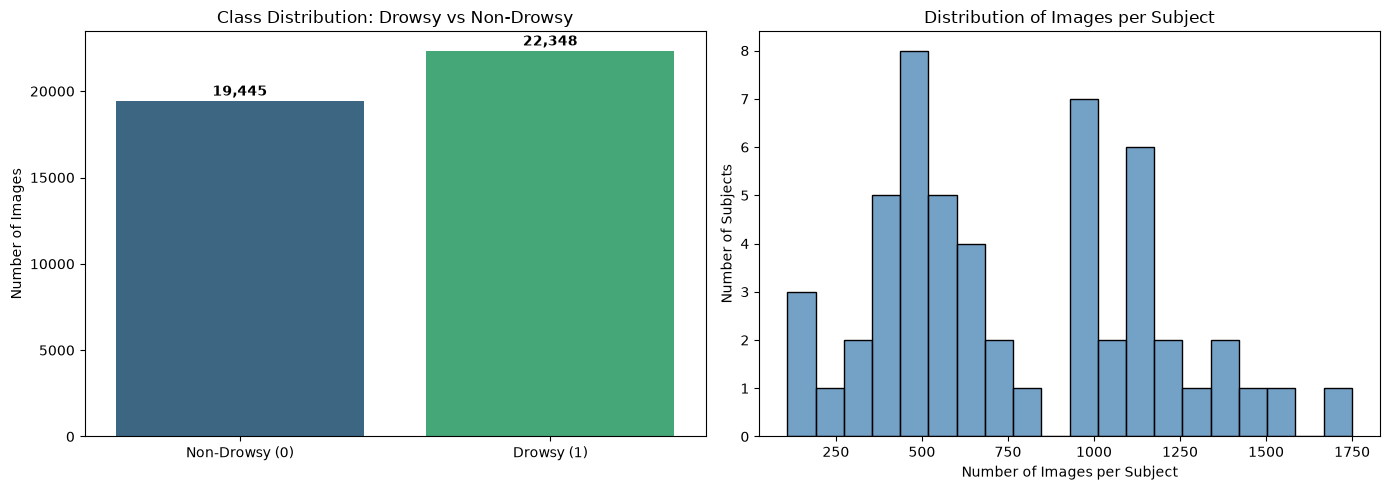

Images per subject - min: 109, max: 1749, mean: 773.9


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts_series = drowsiness_dataset_df['drowsiness_label'].value_counts().sort_index()
class_labels = ['Non-Drowsy (0)', 'Drowsy (1)']

sns.barplot(x=class_labels, y=class_counts_series.values, hue=class_labels, legend=False, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution: Drowsy vs Non-Drowsy')
axes[0].set_ylabel('Number of Images')
for index, count_value in enumerate(class_counts_series.values):
    axes[0].text(index, count_value + 300, f'{count_value:,}', ha='center', fontweight='bold')

images_per_subject_series = drowsiness_dataset_df.groupby('subject_id').size().sort_values(ascending=False)
sns.histplot(images_per_subject_series.values, bins=20, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of Images per Subject')
axes[1].set_xlabel('Number of Images per Subject')
axes[1].set_ylabel('Number of Subjects')

plt.tight_layout()
plt.show()

print(f"Images per subject - min: {images_per_subject_series.min()}, "
      f"max: {images_per_subject_series.max()}, "
      f"mean: {images_per_subject_series.mean():.1f}")

### Interpretation

> * The class distribution bar chart confirms the earlier value counts: **22,348 drowsy** vs. **19,445 non-drowsy** images, a mild ~7 percentage point **class-level imbalance** that does not require resampling.
> * The images-per-subject histogram reveals a **bimodal distribution** rather than a uniform one - subjects cluster into two groups: one around 400–650 images and another around 950–1,150 images, with a visible gap between them. This may indicate that the dataset was collected under different recording conditions, such as different session durations or frame rates per subject, rather than each subject contributing a similar, fixed number of frames.
> * The spread is substantial: images per subject range from a **minimum of 109 to a maximum of 1,749** (a ~16x difference), with a **mean of 773.9**. This confirms a meaningful **subject-level contribution imbalance** (distinct from the mild class-level imbalance above) - a handful of subjects contribute disproportionately more images to the dataset than others.
> * This has a direct implication for the train/validation/test split strategy: a simple random image-level split risks over-representing high-frequency subjects in one partition and under-representing them in another. The planned **subject-level split** (assigning entire subjects to train/val/test rather than individual images) is therefore essential - it prevents both data leakage (same subject's face appearing in train and test) and skewed subject representation across splits.

In [5]:
subject_class_summary_df = drowsiness_dataset_df.groupby('subject_id')['drowsiness_label'].agg(
    total_images='count',
    drowsy_images='sum'
)
subject_class_summary_df['non_drowsy_images'] = (
    subject_class_summary_df['total_images'] - subject_class_summary_df['drowsy_images']
)
subject_class_summary_df['drowsy_ratio'] = (
    subject_class_summary_df['drowsy_images'] / subject_class_summary_df['total_images']
)

print(f"Subjects with ONLY drowsy images: {(subject_class_summary_df['drowsy_ratio'] == 1.0).sum()}")
print(f"Subjects with ONLY non-drowsy images: {(subject_class_summary_df['drowsy_ratio'] == 0.0).sum()}")
print(f"Subjects with BOTH classes present: {((subject_class_summary_df['drowsy_ratio'] > 0) & (subject_class_summary_df['drowsy_ratio'] < 1)).sum()}")

print("\nDrowsy ratio per subject - summary statistics:")
print(subject_class_summary_df['drowsy_ratio'].describe())

subject_class_summary_df.sort_values('total_images', ascending=False).head(10)

Subjects with ONLY drowsy images: 28
Subjects with ONLY non-drowsy images: 26
Subjects with BOTH classes present: 0

Drowsy ratio per subject - summary statistics:
count    54.000000
mean      0.518519
std       0.504349
min       0.000000
25%       0.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: drowsy_ratio, dtype: float64


,total_images,drowsy_images,non_drowsy_images,drowsy_ratio
subject_id,,,,
Drowsy_X,1749,1749,0,1.0
Drowsy_ZB,1551,1551,0,1.0
Non Drowsy_y,1500,0,1500,0.0
Drowsy_A,1411,1411,0,1.0
Drowsy_ZC,1346,1346,0,1.0
Non Drowsy_zc,1288,0,1288,0.0
Non Drowsy_a,1252,0,1252,0.0
Non Drowsy_zb,1237,0,1237,0.0
Drowsy_W,1162,1162,0,1.0


### Interpretation

> * Every subject contributes images from exactly one class only - 28 subjects are exclusively drowsy and 26 are exclusively non-drowsy, with zero subjects containing both classes. The `drowsy_ratio` distribution is therefore fully separated (25th percentile = 0.0, 50th percentile = 1.0, 75th percentile = 1.0), confirming that subjects belong entirely to one class rather than having a mixture of both.
> * This means `subject_id` perfectly determines `drowsiness_label` in this dataset - each subject is associated with either the drowsy or the non-drowsy class, rather than both. This suggests that the class assignment was made at the subject/recording-session level rather than at the individual-frame level. This is also reflected in the subject naming convention (`Drowsy_X`, `Non Drowsy_y`, etc.), which appears to encode the class in the subject identifier.
> * This finding is consistent with the earlier observations about the images-per-subject distribution: the dataset consists of two distinct subject pools, one drowsy-only and one non-drowsy-only. The mild class-level image imbalance (53.5% drowsy vs. 46.5% non-drowsy) is therefore influenced by both the number of subjects in each class (28 vs. 26) and the different numbers of images contributed by individual subjects.
> * The critical modeling implication: since class is fully determined by subject, a subject-level split is essential for evaluating generalization to unseen individuals. Any image-level random split would place images from the same subject in both train and test, potentially allowing the model to exploit subject-specific characteristics such as facial appearance, lighting, camera angle, or background instead of learning generalizable drowsiness cues. Reported test performance under an image-level split could therefore be artificially inflated and would not reliably reflect performance on unseen subjects. When creating the subject-level split, the drowsy and non-drowsy subject groups should also be represented appropriately across train, validation, and test sets.

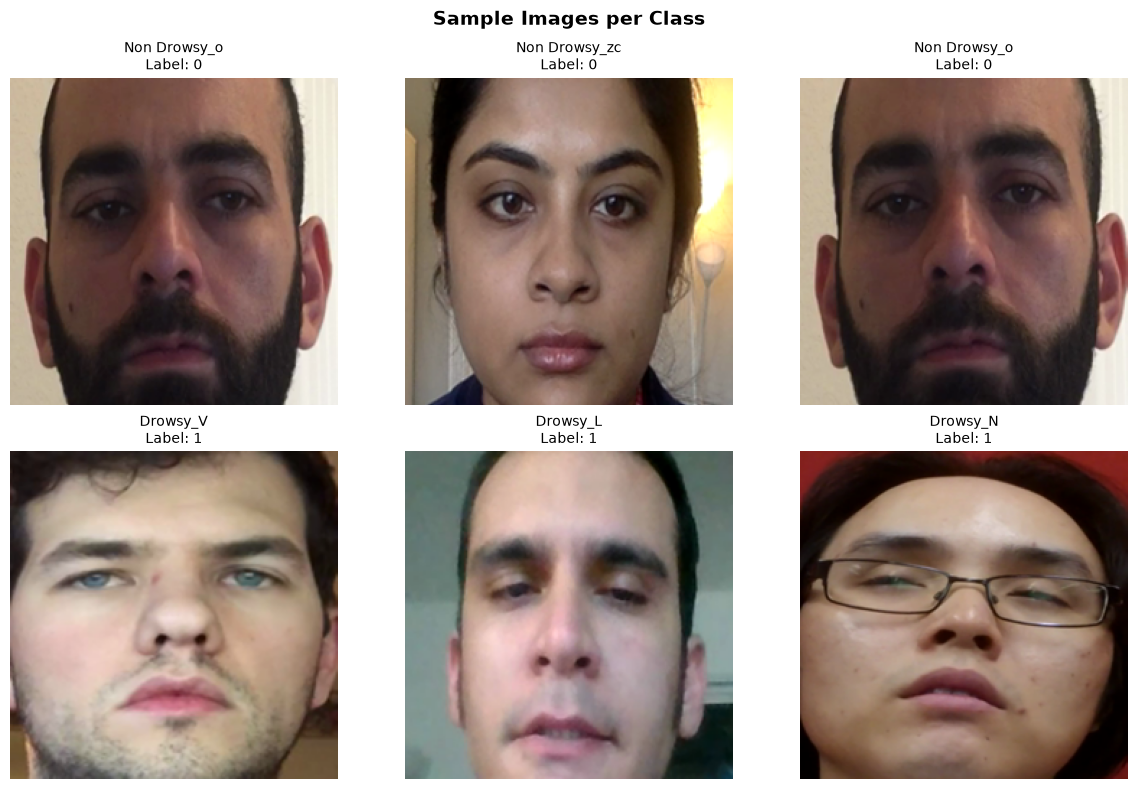

In [6]:
sample_images_per_class = 3
fig, axes = plt.subplots(2, sample_images_per_class, figsize=(12, 8))

for class_index, class_label in enumerate([0, 1]):
    class_subset_df = drowsiness_dataset_df[
        drowsiness_dataset_df['drowsiness_label'] == class_label
    ]
    sampled_rows_df = class_subset_df.sample(n=sample_images_per_class, random_state=42)

    for column_index, (_, row) in enumerate(sampled_rows_df.iterrows()):
        image = plt.imread(row['image_filepath'])
        axes[class_index, column_index].imshow(image)
        axes[class_index, column_index].set_title(
            f"{row['subject_id']}\nLabel: {row['drowsiness_label']}", fontsize=10
        )
        axes[class_index, column_index].axis('off')

fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation

> * Visual inspection of the sampled images shows that the labels are consistent with the visible drowsiness state: non-drowsy samples generally show subjects with open eyes and an alert, forward-facing appearance, while drowsy samples show closed or near-closed eyes and drooping eyelids. This provides a visual sanity check that the two classes represent distinguishable drowsiness states.
> * The sampled images also show variation in facial appearance, facial hair, eyewear (one drowsy subject wears glasses), and background/lighting conditions (e.g. the red-tinted background in one drowsy sample vs. more neutral backgrounds elsewhere). This suggests that the dataset contains some variation in appearance and recording conditions rather than a completely uniform visual setup.
> * One subject (`Non Drowsy_o`) appears twice in the 3-image non-drowsy sample, indicating that the sampling was performed at the image level rather than selecting unique subjects. This is not an error and is expected when multiple images from the same subject are available. However, this example also highlights why image-level sampling and splitting must be distinguished from subject-level splitting: multiple images from the same individual can easily appear in the same sample or, more importantly, across different dataset splits if subjects are not explicitly kept together.
> * Overall, the visual inspection provides a useful sanity check on the dataset labels and shows that drowsiness-related visual cues are present in the images. However, these examples alone are not sufficient to assess the generalization of the dataset; the earlier subject-level analysis and split strategy remain essential for preventing subject overlap between train, validation, and test sets.

In [7]:
from data_utils import subject_level_split, print_split_summary

train_images_df, val_images_df, test_images_df = subject_level_split(drowsiness_dataset_df)
print_split_summary(train_images_df, val_images_df, test_images_df)

Train | images:  29290 | subjects:  31 | class balance (0=Non Drowsy, 1=Drowsy): {1: 0.535, 0: 0.465}
Val   | images:   6165 | subjects:  11 | class balance (0=Non Drowsy, 1=Drowsy): {1: 0.539, 0: 0.461}
Test  | images:   6338 | subjects:  12 | class balance (0=Non Drowsy, 1=Drowsy): {1: 0.528, 0: 0.472}


### Interpretation

> * The subject-level split allocated 31 subjects (29,290 images, 70.0%) to Train, 11 subjects (6,165 images, 14.8%) to Validation, and 12 subjects (6,338 images, 15.2%) to Test - closely matching the target 70/15/15 ratio.
> * Critically, the class balance is now nearly identical across all three splits: 53.5% drowsy in Train, 53.9% in Validation, 52.8% in Test - a spread of only ~1.1 percentage points. This indicates that the split successfully distributes the two classes consistently across the three partitions while keeping subjects separated.
> * This provides a suitable basis for training and evaluation: each partition has a class composition close to that of the full dataset (~53.5% drowsy / ~46.5% non-drowsy), reducing the risk that differences in model performance are caused by substantially uneven class representation between the splits. However, performance differences may still reflect differences in subject characteristics and difficulty across the partitions.
> * As established earlier, keeping entire subjects within a single partition is essential for preventing subject-level data leakage. Assuming the `_assert_no_subject_overlap()` validation passes, the absence of subject overlap, combined with the consistent class distribution, provides a methodologically sound foundation for Section 6 (Preprocessing) and Section 7 (Modeling).

***

## 6. Preprocessing

Before training, the raw images need to be converted into a format suitable for a convolutional neural network:

- **Resizing** - all images are resized to a fixed target size (145×145 px), since a CNN requires a consistent input shape across all samples, while the raw DDD images may vary slightly in dimensions.
- **Grayscale conversion** - the images are loaded in grayscale rather than RGB. Drowsiness cues (eye closure, eyelid droop) are structural/shape-based rather than color-based, so grayscale reduces input dimensionality and computational cost without discarding relevant information.
- **Normalization** - pixel values are rescaled from the [0, 255] range to [0, 1] by dividing by 255. This keeps input values in a small, consistent range, which helps gradient-based optimization converge faster and more stably.
- **Data augmentation (training set only)** - random rotation, zoom, brightness shifts, and small width/height shifts are applied to the training images on the fly during training. This artificially increases the diversity of the training data and reduces overfitting, which is particularly important given the limited number of unique subjects (54) in this dataset. Horizontal flipping is intentionally **not** used, since face orientation (e.g. head tilt direction) may itself carry information relevant to drowsiness.
- **No augmentation on validation/test sets** - these sets are only rescaled, never augmented, since they must reflect realistic, unmodified data to give a reliable estimate of model performance.

This preprocessing pipeline is implemented in `build_data_generators()` in `data_utils.py`, which returns three Keras `ImageDataGenerator` flows (train, validation, test) built directly from the subject-level split created in Section 5.

### Key Formulas

* <u>Min-Max Normalization</u>
1. *Definition* -> a data preprocessing technique that rescales values so that all numeric values fall within a specific, bounded range - typically [0, 1] - by scaling relative to the minimum and maximum of the original range.
2. *Formula*:
$$ x_{normalized} = \frac{x - x_{min}}{x_{max} - x_{min}} $$

    -> $x$ is the original data point value; <br>
    -> $x_{min}$ is the minimum value across the entire dataset feature; <br>
    -> $x_{max}$ is the maximum value across the entire dataset feature; <br>
    -> $x_{normalized}$ is the newly scaled value (between 0 and 1).

* <u>Normalization applied to 8-bit pixel intensities</u>
1. *Definition* -> the specific case of min-max normalization used for image pixel values, where the minimum and maximum are fixed and known in advance (0 and 255 for 8-bit images), rather than computed from the data.
2. *Formula*:
$$ x_{normalized} = \frac{x}{255} $$

    -> $x$ is the original pixel intensity, in the range [0, 255]; <br>
    -> dividing by the fixed maximum (255) rescales every pixel to the [0, 1] range, which helps gradient-based optimizers (e.g. Adam, SGD) converge faster and more stably during training.

In [8]:
from data_utils import build_data_generators

train_generator, val_generator, test_generator = build_data_generators(
    train_images_df.copy(), val_images_df.copy(), test_images_df.copy()
)

C:\Users\djuli\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.1)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


Found 29290 validated image filenames belonging to 2 classes.
Found 6165 validated image filenames belonging to 2 classes.
Found 6338 validated image filenames belonging to 2 classes.


### Interpretation

> * The three `ImageDataGenerator` flows were built successfully, confirming **29,290 training images**, **6,165 validation images**, and **6,338 test images** - matching exactly the split sizes established in Section 5. Each generator correctly identified **2 classes** (Drowsy / Non Drowsy) from the `drowsiness_label` column.
> * As designed, the training generator applies on-the-fly augmentation (rotation, zoom, brightness, width/height shifts) and shuffles data each epoch, while the validation and test generators only rescale pixel values and preserve the original image order (`shuffle=False`). This ordering is important later because it allows predictions to be correctly matched with their corresponding true labels when generating the confusion matrix and classification report in Section 8.

Found 6 validated image filenames belonging to 2 classes.


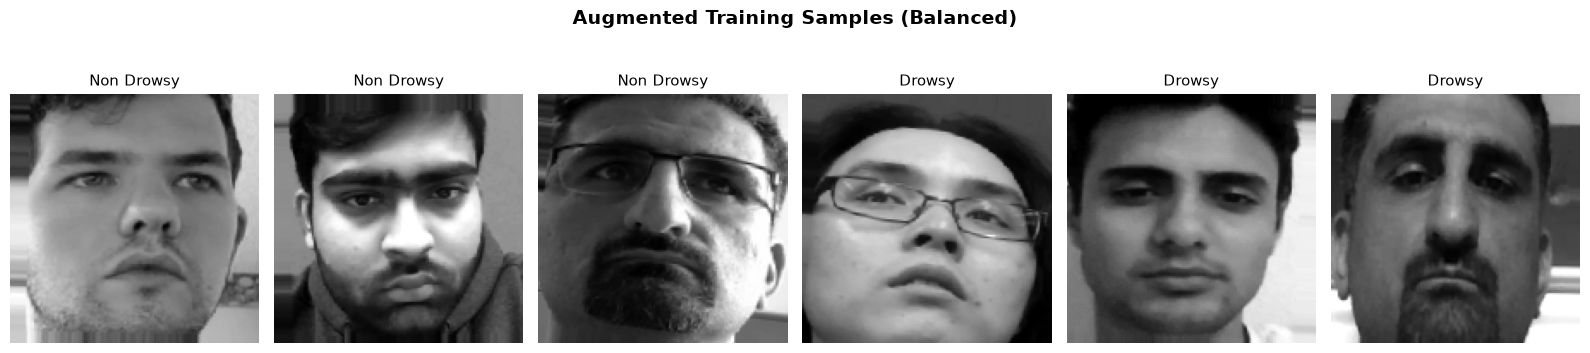

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sample_drowsy_df = train_images_df[train_images_df['drowsiness_label'] == 1].sample(n=3)
sample_non_drowsy_df = train_images_df[train_images_df['drowsiness_label'] == 0].sample(n=3)
balanced_sample_df = pd.concat([sample_drowsy_df, sample_non_drowsy_df]).sample(frac=1).reset_index(drop=True)
balanced_sample_df['drowsiness_label'] = balanced_sample_df['drowsiness_label'].astype(str)

demo_augmenter = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=(0.8, 1.2),
    width_shift_range=0.05,
    height_shift_range=0.05,
)

demo_generator = demo_augmenter.flow_from_dataframe(
    balanced_sample_df,
    x_col='image_filepath',
    y_col='drowsiness_label',
    target_size=(145, 145),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=6,
    shuffle=False,
)

sample_batch_images, sample_batch_labels = next(demo_generator)

fig, axes = plt.subplots(1, 6, figsize=(16, 4))
for i in range(6):
    axes[i].imshow(sample_batch_images[i].squeeze(), cmap='gray')
    label_text = 'Drowsy' if sample_batch_labels[i] == 1 else 'Non Drowsy'
    axes[i].set_title(label_text, fontsize=11)
    axes[i].axis('off')

fig.suptitle('Augmented Training Samples (Balanced)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation

> * The augmented training samples provide a visual check that the preprocessing pipeline is producing usable model inputs: the images are displayed in grayscale, facial regions remain clearly visible, and the drowsiness-relevant features (particularly eye and eyelid appearance) are preserved after preprocessing and augmentation.
> * The samples show visible variation between executions, consistent with the application of on-the-fly augmentation transformations such as rotation, shifts, zoom, and brightness changes. The transformations do not appear to distort the facial features to the point of obscuring the relevant visual cues.
> * The sample was constructed to explicitly draw 3 Drowsy and 3 Non-Drowsy images (rather than relying on a single random batch from the full shuffled generator), so both classes are always represented in the visualization. The specific subjects and augmentation transformations shown will still vary between executions, since the underlying images and augmentation parameters are sampled randomly each time - only the class balance of the displayed batch is fixed.
> * A closer look at individual samples can also illustrate a potential source of label noise inherent to this dataset: since labels are assigned at the subject/recording-session level rather than per individual frame (as established in Section 5), not every frame within a "drowsy" session necessarily shows visibly closed or drooping eyes, while some frames within a "non-drowsy" session may contain blinking or a downward glance that visually resembles drowsiness. This session-level labeling is a limitation of the dataset itself rather than an error in the preprocessing pipeline, and it means that the model may be exposed to some frame-level label noise during training.